In [1]:
import numpy as np

In [2]:
import tensorflow as tf 

In [6]:
import pandas as pd

In [7]:
import matplotlib.pyplot as plt 

In [8]:
df = pd.read_csv(r'C:\\Users\\Arjun Singh Tomar\\Downloads\\digit-recognizer\\train.csv')

In [9]:
df.head()

,label,pixel0,pixel1,pixel2,pixel3,pixel4,pixel5,pixel6,pixel7,pixel8,...,pixel774,pixel775,pixel776,pixel777,pixel778,pixel779,pixel780,pixel781,pixel782,pixel783
0,1,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,1,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,4,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [10]:
X = df.drop("label",axis = 1)

In [11]:
y = df['label']

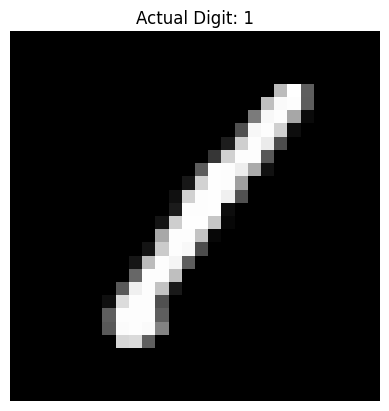

In [12]:
image = X.iloc[0].values.reshape(28, 28)

plt.imshow(image, cmap="gray")
plt.title(f"Actual Digit: {y.iloc[0]}")
plt.axis("off")
plt.show()


In [13]:
from sklearn.model_selection import train_test_split

In [14]:
X_train,X_test,y_train,y_test = train_test_split(
    X,y,test_size = 0.2,random_state = 42
)

In [15]:
# Normalize the value 
X_train = X_train / 255.0
X_test = X_test / 255.0 

In [16]:
# convert to numpy
X_train = X_train.values
X_test = X_test.values
y_train = y_train.values
y_test = y_test.values


In [17]:
model  = tf.keras.Sequential([
    tf.keras.layers.Input(shape=(784,)),
    tf.keras.layers.Dense(128,activation='relu'),
    tf.keras.layers.Dense(64,activation='relu'),
    tf.keras.layers.Dense(10,activation='softmax')   # gives 10 output 
])

In [18]:
model.compile(
    optimizer ="adam",
    loss = 'sparse_categorical_crossentropy',
    metrics = ['accuracy']
)

In [19]:
model.fit(X_train,y_train,epochs= 10,batch_size = 32,validation_split=0.1)

Epoch 1/10
945/945 ━━━━━━━━━━━━━━━━━━━━ 7s 6ms/step - accuracy: 0.9037 - loss: 0.3239 - val_accuracy: 0.9551 - val_loss: 0.1557
Epoch 2/10
945/945 ━━━━━━━━━━━━━━━━━━━━ 10s 5ms/step - accuracy: 0.9593 - loss: 0.1328 - val_accuracy: 0.9646 - val_loss: 0.1193
Epoch 3/10
945/945 ━━━━━━━━━━━━━━━━━━━━ 10s 5ms/step - accuracy: 0.9725 - loss: 0.0900 - val_accuracy: 0.9655 - val_loss: 0.1145
Epoch 4/10
945/945 ━━━━━━━━━━━━━━━━━━━━ 5s 5ms/step - accuracy: 0.9789 - loss: 0.0660 - val_accuracy: 0.9753 - val_loss: 0.0882
Epoch 5/10
945/945 ━━━━━━━━━━━━━━━━━━━━ 5s 6ms/step - accuracy: 0.9844 - loss: 0.0502 - val_accuracy: 0.9747 - val_loss: 0.0938
Epoch 6/10
945/945 ━━━━━━━━━━━━━━━━━━━━ 5s 5ms/step - accuracy: 0.9882 - loss: 0.0387 - val_accuracy: 0.9673 - val_loss: 0.1290
Epoch 7/10
945/945 ━━━━━━━━━━━━━━━━━━━━ 10s 5ms/step - accuracy: 0.9893 - loss: 0.0320 - val_accuracy: 0.9708 - val_loss: 0.1050
Epoch 8/10
945/945 ━━━━━━━━━━━━━━━━━━━━ 5s 5ms/step - accuracy: 0.9903 - loss: 0.0281 - val_accuracy:

In [24]:
loss,accuracy = model.evaluate(X_test,y_test,verbose=0)

In [25]:
print(loss)

0.13054560124874115


In [26]:
print(accuracy)

0.9680952429771423


In [32]:
prediction = model.predict(X_test)

263/263 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step


Predicted Digit: 62
Actual Digit: 8


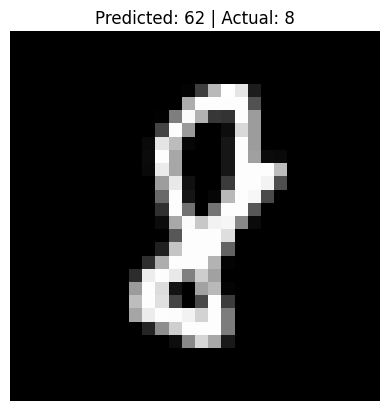

In [33]:
predicted_digit = np.argmax(prediction)

print("Predicted Digit:", predicted_digit)
print("Actual Digit:", y_test[0])


# Show prediction
plt.imshow(X_test[0].reshape(28, 28), cmap="gray")
plt.title(f"Predicted: {predicted_digit} | Actual: {y_test[0]}")
plt.axis("off")
plt.show()